In [16]:
import pandas as pd

df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
print(df.head())

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split


df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df = df.drop(columns=['Blood Pressure', 'Person ID'])
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')



In [18]:
# Exploratory Data Analysis
print("Dataset Shape:", df.shape)
print("\nDataset Information")
print(df.info())
print("\nSummary Statistics")
display(df.describe(include="all"))

Dataset Shape: (374, 13)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic                 374 non-null    int64  
 12  Diastolic                374 non-null    int64  
dtypes: float64(1), int64(8), object(4)

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
count,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374.000000,374.000000,374,374.000000,374.000000
unique,2,NaN,11,NaN,NaN,NaN,NaN,4,NaN,NaN,3,NaN,NaN
top,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,NaN,NaN,None,NaN,NaN
freq,189,NaN,73,NaN,NaN,NaN,NaN,195,NaN,NaN,219,NaN,NaN
mean,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,70.165775,6816.844920,NaN,128.553476,84.649733
std,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,4.135676,1617.915679,NaN,7.748118,6.161611
min,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,65.000000,3000.000000,NaN,115.000000,75.000000
25%,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,68.000000,5600.000000,NaN,125.000000,80.000000
50%,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,70.000000,7000.000000,NaN,130.000000,85.000000
75%,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,72.000000,8000.000000,NaN,135.000000,90.000000


In [19]:
# Separating Target from Features
X = df.drop(columns=['Sleep Disorder'], axis=1)
y = df['Sleep Disorder']



Exploratory Data Analysis (EDA)

Before training the model, the dataset is explored to understand
its structure, identify missing values, examine feature
distributions and determine whether the target classes are balanced.

In [27]:
print("Dataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
display(df.describe(include="all"))

Dataset Shape: (374, 13)

Missing Values
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic                   0
Diastolic                  0
dtype: int64

Summary Statistics


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
count,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374.000000,374.000000,374,374.000000,374.000000
unique,2,NaN,11,NaN,NaN,NaN,NaN,4,NaN,NaN,3,NaN,NaN
top,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,NaN,NaN,None,NaN,NaN
freq,189,NaN,73,NaN,NaN,NaN,NaN,195,NaN,NaN,219,NaN,NaN
mean,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,70.165775,6816.844920,NaN,128.553476,84.649733
std,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,4.135676,1617.915679,NaN,7.748118,6.161611
min,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,65.000000,3000.000000,NaN,115.000000,75.000000
25%,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,68.000000,5600.000000,NaN,125.000000,80.000000
50%,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,70.000000,7000.000000,NaN,130.000000,85.000000
75%,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,72.000000,8000.000000,NaN,135.000000,90.000000


In [20]:
print("Missing Values")
missing = df.isnull().sum()
display(missing[missing > 0])

Missing Values


Series([], dtype: int64)

Feature Skewness


Heart Rate                 1.224824
Diastolic                  0.378570
Age                        0.257222
Daily Steps                0.178277
Stress Level               0.154330
Physical Activity Level    0.074487
Sleep Duration             0.037554
Systolic                  -0.035669
Quality of Sleep          -0.207448
dtype: float64

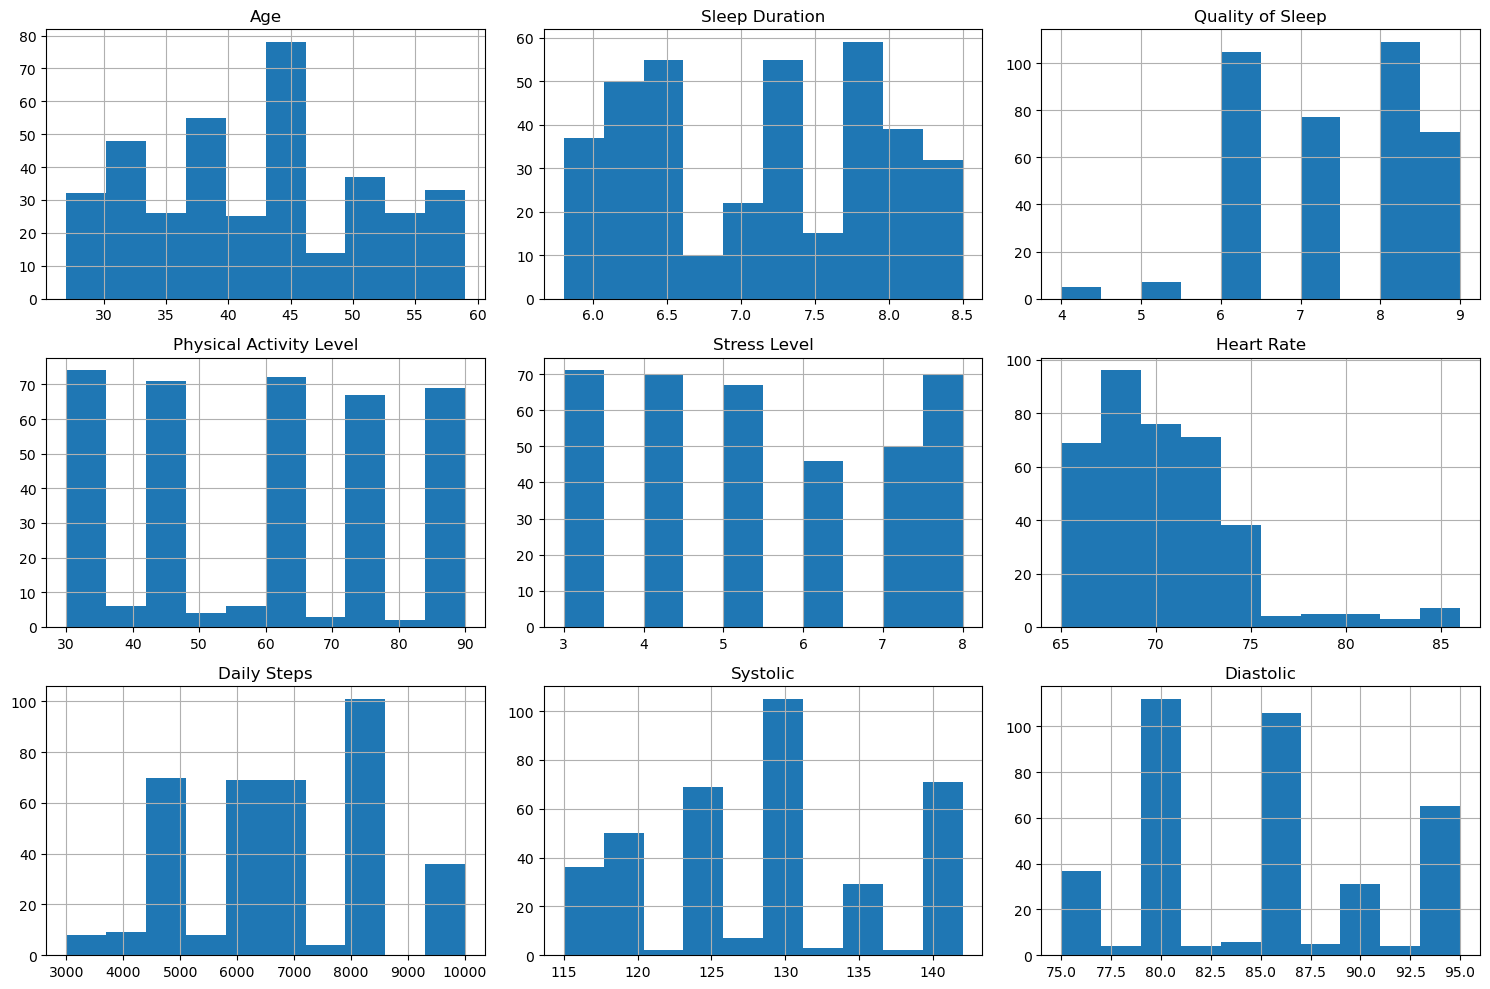

In [21]:
import matplotlib.pyplot as plt
# Select numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
# Calculate skewness
skewness = df[numerical_cols].skew().sort_values(ascending=False)
print("Feature Skewness")
display(skewness)
# Plot histograms
df[numerical_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

In [22]:
print("Sleep Disorder Class Distribution")

class_counts = df["Sleep Disorder"].value_counts()

display(class_counts)

print("\nPercentages")

display(round(class_counts / len(df) * 100,2))

Sleep Disorder Class Distribution


Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


Percentages


Sleep Disorder
None           58.56
Sleep Apnea    20.86
Insomnia       20.59
Name: count, dtype: float64

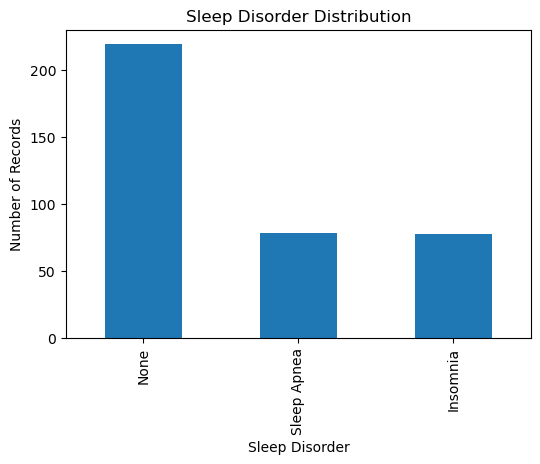

In [23]:
#visualization
plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Sleep Disorder Distribution")
plt.xlabel("Sleep Disorder")
plt.ylabel("Number of Records")
plt.show()


In [24]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Balancing

In [25]:
from sklearn.utils import resample

# Combine features and labels
train_df = pd.concat([X_train, y_train], axis=1)

# Find the size of the largest class
max_size = train_df["Sleep Disorder"].value_counts().max()

balanced_data = []

# Oversample each class
for label in train_df["Sleep Disorder"].unique():

    subset = train_df[train_df["Sleep Disorder"] == label]

    balanced_subset = resample(
        subset,
        replace=True,
        n_samples=max_size,
        random_state=42
    )

    balanced_data.append(balanced_subset)

# Combine balanced data
balanced_train = pd.concat(balanced_data)

# Shuffle
balanced_train = balanced_train.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Separate features and target again
X_train = balanced_train.drop("Sleep Disorder", axis=1)

y_train = balanced_train["Sleep Disorder"]

Sleep Disorder
Sleep Apnea    175
Insomnia       175
None           175
Name: count, dtype: int64


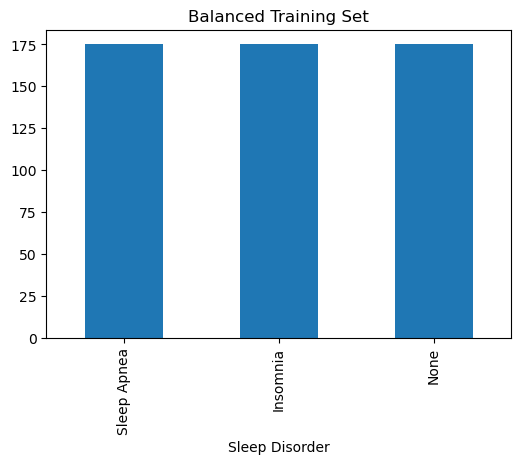

In [26]:
print(y_train.value_counts())

plt.figure(figsize=(6,4))

y_train.value_counts().plot(kind="bar")

plt.title("Balanced Training Set")

plt.show()

Augmenting training data


In [3]:
import numpy as np

# Recombining train temporarily so we can bootstrap it
train_df = X_train.copy()
train_df['Sleep Disorder'] = y_train

# Expanding the training data
target_size = 5500
train_df = train_df.sample(n=target_size, replace=True, random_state=42).reset_index(drop=True)

# Adding natural noise to training data
noise_profiles = {
    'Sleep Duration': 0.5, 'Quality of Sleep': 0.5, 'Physical Activity Level': 10.0, 
    'Stress Level': 0.5, 'Heart Rate': 3.0, 'Daily Steps': 800.0, 
    'Systolic': 4.0, 'Diastolic': 3.0
}
train_df['Age'] = train_df['Age'] + np.random.randint(-1, 2, size=len(train_df))
for col, std_dev in noise_profiles.items():
    train_df[col] = train_df[col] + np.random.normal(0, std_dev, size=len(train_df))


for col in ['Quality of Sleep', 'Stress Level']:
    train_df[col] = train_df[col].clip(1, 10).round(1)
for col in ['Age', 'Daily Steps', 'Systolic', 'Diastolic', 'Heart Rate', 'Physical Activity Level']:
    train_df[col] = train_df[col].clip(lower=0).round(0).astype(int)
train_df['Sleep Duration'] = train_df['Sleep Duration'].clip(lower=0).round(1)

# 4. Inject NaNs into both
def inject_nans(data):
    data.loc[data[data['Age'] > 40].sample(frac=0.15, random_state=42).index, 'Sleep Duration'] = np.nan
    data.loc[data[data['Daily Steps'] < 4000].sample(frac=0.20, random_state=42).index, 'Heart Rate'] = np.nan
    data.loc[data.sample(frac=0.03, random_state=42).index, 'BMI Category'] = np.nan
    return data

train_df = inject_nans(train_df)
X_test = inject_nans(X_test.copy())

# Separate train features and target again
X_train = train_df.drop(columns=['Sleep Disorder'])
y_train = train_df['Sleep Disorder']

print(f"Training data augmented! Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Training data augmented! Train shape: (5500, 12), Test shape: (75, 12)


The Cleanup (Imputing & Encoding), then Spliting and Scaling

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Imputing
num_imputer = SimpleImputer(strategy='median')
X_train[['Sleep Duration', 'Heart Rate']] = num_imputer.fit_transform(X_train[['Sleep Duration', 'Heart Rate']])
X_test[['Sleep Duration', 'Heart Rate']] = num_imputer.transform(X_test[['Sleep Duration', 'Heart Rate']])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[['BMI Category']] = cat_imputer.fit_transform(X_train[['BMI Category']])
X_test[['BMI Category']] = cat_imputer.transform(X_test[['BMI Category']])

# Encoding
label_encoders = {}
for col in ['Gender', 'Occupation', 'BMI Category']:
    le = LabelEncoder()

    le.fit(X_train[col].astype(str))

    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# Encode target separately
le_y = LabelEncoder()
y_train = le_y.fit_transform(y_train)
y_test = le_y.transform(y_test)
label_encoders['Sleep Disorder'] = le_y

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Imputation, Encoding, and Scaling complete")

Imputation, Encoding, and Scaling complete


Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Training the model


model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Predicting and Grading
predictions = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)


print(f"Accuracy Score: {accuracy * 100:.2f}%\n")
print(classification_report(y_test, predictions, target_names=label_encoders['Sleep Disorder'].classes_))

Accuracy Score: 96.00%

              precision    recall  f1-score   support

    Insomnia       0.88      0.93      0.90        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.93      0.88      0.90        16

    accuracy                           0.96        75
   macro avg       0.94      0.94      0.94        75
weighted avg       0.96      0.96      0.96        75



In [6]:
import joblib

# Export the trained model, the math scaler, and the text translators
joblib.dump(model, 'sleep_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'encoders.pkl')

print("Exported successfully!")

Exported successfully!


How Bias was addressed:
Class Imbalance (stratify=y) - By stratifying the split

Magnitude Bias (StandardScaler) - Scaling

Outlier Bias (.clip()) - Clipping the extreme highs and lows.